# Visualization Principles

Before we learn *how* to write the code for complex interactive dashboards, we must first learn *what* makes a visualization effective. Great data visualization is not about making things look "pretty"—it is about reducing cognitive load. You want the viewer to understand your core message in under 5 seconds.

To achieve this, we follow three core principles:
1. **Chart Selection**: Pick the right tool for the job.
2. **The Data-to-Ink Ratio**: Remove the noise.
3. **Visual Hierarchy**: Guide the eye to what matters.

Let's set up a Python sandbox using `matplotlib` and `seaborn` to see these principles in action.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create a dataset: Quarterly Sales across 4 different Regions
data = {
    'Region': ['North', 'South', 'East', 'West'] * 4,
    'Quarter': ['Q1']*4 + ['Q2']*4 + ['Q3']*4 + ['Q4']*4,
    'Sales': [120, 90, 110, 105,  135, 95, 115, 110,  150, 85, 100, 130,  180, 80, 95, 140]
}

df = pd.DataFrame(data)
print("✅ Sales Dataset loaded!")

✅ Sales Dataset loaded!


# Principle 1: Chart Selection
The biggest mistake beginners make is choosing a chart because it looks cool (like a 3D Exploding Pie Chart). You must choose a chart based entirely on the **relationship** you are trying to show:

* **Comparison** (Who sold the most?): **Bar Chart**
* **Trend over Time** (Are sales going up?): **Line Chart**
* **Distribution** (Where do most of our customers live?): **Histogram or Boxplot**
* **Relationship** (Does spending more on ads increase sales?): **Scatterplot**


*Rule of Thumb: Never use a Pie Chart if you have more than 3 categories. The human eye is terrible at judging the size of angles compared to straight lines.*

# Principle 2: The Data-to-Ink Ratio (Reducing Noise)
Coined by data pioneer Edward Tufte, the **Data-to-Ink Ratio** states that every drop of "ink" on a chart should be used to represent data. If the ink is not representing data (like heavy gridlines, dark background colors, or 3D borders), it is "noise" and should be deleted.

Let's look at how to ruin a chart with noise.

/tmp/ipykernel_10923/1747182978.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['Quarter'] == 'Q4'], x='Region', y='Sales',


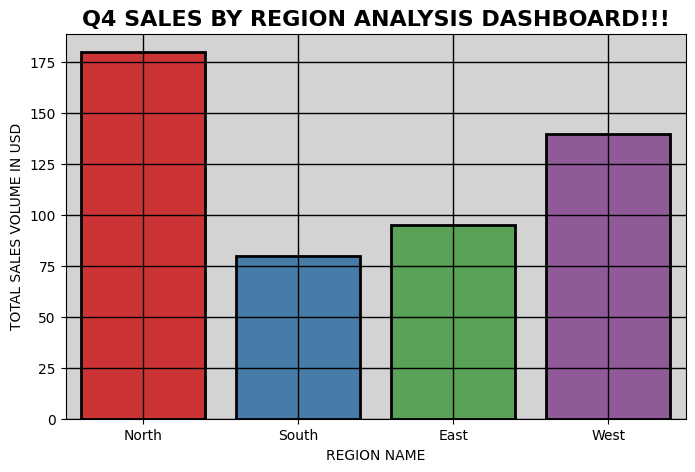

In [2]:
# ❌ THE BAD CHART (Low Data-to-Ink Ratio) ❌
plt.figure(figsize=(8, 5))

# Using a chaotic color palette for no reason, adding black borders
sns.barplot(data=df[df['Quarter'] == 'Q4'], x='Region', y='Sales', 
            palette='Set1', edgecolor='black', linewidth=2)

# Adding unnecessary noise
plt.title("Q4 SALES BY REGION ANALYSIS DASHBOARD!!!", fontsize=16, fontweight='bold')
plt.xlabel("REGION NAME")
plt.ylabel("TOTAL SALES VOLUME IN USD")
plt.grid(color='black', linestyle='-', linewidth=1) # Heavy, distracting gridlines
plt.gca().set_facecolor('lightgray') # Unnecessary background color

plt.show()

*Why this is bad: The heavy gridlines fight with the bars for attention. The background color adds zero information. Every bar is a completely different, highly saturated color, which tricks the brain into thinking the colors mean something special (they don't, they just represent the X-axis labels).*

# Principle 3: Visual Hierarchy (Pre-attentive Attributes)
**Pre-attentive attributes** are visual signals that our brains process before we even consciously think about them (like Color, Size, and Contrast). 

If your goal is to show the CEO that the **North Region** had a massive breakout quarter, you shouldn't make them search for it. You should use color strategically to highlight the North, and mute everything else into the background.

/tmp/ipykernel_10923/3113890078.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df[df['Quarter'] == 'Q4'], x='Region', y='Sales', palette=colors)


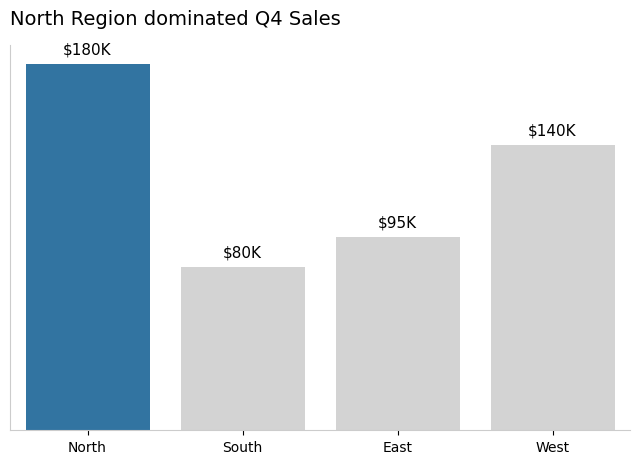

In [3]:
# ✅ THE GOOD CHART (High Data-to-Ink Ratio & Visual Hierarchy) ✅
plt.figure(figsize=(8, 5))

# 1. Visual Hierarchy: Mute the normal data (gray), highlight the important data (blue)
colors = ['#1f77b4' if region == 'North' else '#d3d3d3' for region in df[df['Quarter'] == 'Q4']['Region']]

# Create the clean bar plot
ax = sns.barplot(data=df[df['Quarter'] == 'Q4'], x='Region', y='Sales', palette=colors)

# 2. Reduce Noise: Remove the top and right borders (spines)
ax.spines['top'].set_visible(False)
ax.single_spine_right = ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

# 3. Clean Labels: The title should state the INSIGHT, not just describe the axes
plt.title("North Region dominated Q4 Sales", fontsize=14, loc='left', pad=15)
plt.xlabel("") # We don't need to say "Region", it's obvious from the labels
plt.ylabel("") # We will label the bars directly instead of using a Y-axis!
plt.yticks([]) # Remove the Y-axis ticks completely to save ink

# 4. Direct Labeling: Put the exact numbers right on top of the bars
for p in ax.patches:
    ax.annotate(f"${int(p.get_height())}K", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')

plt.show()

*Why this is great: It takes exactly one second to understand the message. The title tells you what happened. The blue color instantly draws your eye to the North region. The gray bars provide context without distracting. We deleted the Y-axis and gridlines entirely, replacing them with clean, direct labels.*

---

## Real-World Use Case or Analogy:
Think of Visualization Principles like **Designing a Highway Billboard**:

* **Chart Selection**: Drivers are moving at 70 MPH. You have 3 seconds to deliver a message. You don't put a 500-word essay on a billboard; you put a massive picture of a burger and an arrow pointing to the next exit.
* **Reducing Noise**: If you clutter the billboard with the restaurant's phone number, exact address, names of the staff, and a heavy neon border, the driver's brain will be overloaded and they will miss the core message entirely.
* **Visual Hierarchy**: The word **"FOOD"** is in massive, bright yellow letters. The text "Exit 42" is slightly smaller. The legal disclaimer at the bottom is tiny and gray. You are explicitly controlling the order in which the driver reads the information based on what is most critical for them to know.

---